In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/vega/vega-datasets/master/data/seattle-weather.csv"
df = pd.read_csv(url)

df.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [2]:
print(df.columns)
print(df.shape)
df.head()

Index(['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather'], dtype='object')
(1461, 6)


,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [4]:
df['Tomorrow_Temp'] = df['temp_max'].shift(-1)
df = df.dropna()

In [6]:
features = ['temp_max', 'wind']
X = df[features]
y = df['Tomorrow_Temp']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(1168, 2) (292, 2)


In [8]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [9]:
predictions = model.predict(X_test)

print(predictions[:5])

[25.43481667  9.73333333  7.5282     26.13881667 12.111     ]


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R2 Score: {r2:.2f}')

MAE: 2.51
RMSE: 3.23
R2 Score: 0.82


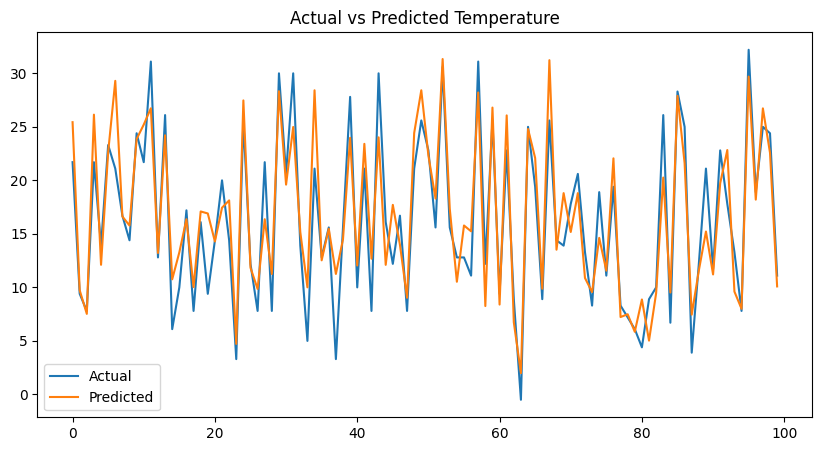

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label='Actual')
plt.plot(predictions[:100], label='Predicted')
plt.legend()
plt.title('Actual vs Predicted Temperature')
plt.show()

In [14]:
sample = pd.DataFrame([[30, 12]], columns=['temp_max', 'wind']) # Temp_max, Wind

pred = model.predict(sample)

print(f'Predicted Tomorrow Temperature: {pred[0]:.2f} °C')

Predicted Tomorrow Temperature: 31.01 °C
